<a href="https://colab.research.google.com/github/Insight-Sogang-Univ/insight-15th/blob/sihyun/advanced/sihyun/session06/assignment%2Ctransferlearning_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/Insight-Sogang-Univ/insight-15th/blob/main/advanced/template/session06/assignment_transferlearning.ipynb" target="_parent">
      <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
    </a>
  </td>
</table>

# 💳 전이학습: 하나카드 고객센터 상담 자동 분류 task

## 📞 시나리오

> 하나카드 고객센터에는 매일 수만 건의 상담 전화가 들어옵니다.  
> AI가 고객의 말을 듣고 **어떤 주제의 문의인지 자동으로 파악**해서 담당 팀으로 연결합니다.
>
> 실습에서 Frozen / Partial / Full Fine-tuning을 해봤다면,  
> 이번엔 **PEFT(LoRA)** 와 **프롬프트 엔지니어링** 을 직접 경험해봅니다.  
> 그리고 두 방법을 **혼합**하면 어떻게 되는지도 확인해보세요!

<br>

### 📍 분류 클래스


| 분류 클래스 (11개) | 예시                                                                     |
| ------------ | ---------------------------------------------------------------------- |
| 결제/출금/연체     | "이번 달 결제 금액이 얼마인가요?"|
| 결제계좌/수단      | "결제 계좌를 다른 은행 계좌로 바꾸고 싶어요."|
| 이용내역/승인      | "취소한 결제가 아직 반영되지 않았어요."                    |
| 한도           | "한도를 상향할 수 있나요?"               |
| 대출           | "리볼빙 서비스를 해지하고 싶어요."          |
| 분실/도난        | "카드를 잃어버렸어요."|
| 이벤트/혜택       |"마일리지를 다른 포인트로 전환하고 싶어요."|
| 바우처/공과금      | "정부지원 바우처를 신청하고 싶어요."|
| 서비스/이용방법     | "하나페이는 어떻게 사용하나요?"|
| 서류/증명        | "소득공제 확인서를 발급받고 싶어요."|
| 기타           | 위 카테고리에 명확하게 해당하지 않는 문의                                                |

<br>


### 📍 과제 구성
- **PEFT (LoRA)** 파라미터 효율적 fine-tuning
- **Gemini 프롬프트 엔지니어링** 학습 없이 분류
- **비교**: PEFT vs 프롬프트 엔지니어링 결과 비교
- **LLM-as-Judge**: 확신도 기반 라우팅

---
## ⚙️ 공통 설정

In [ ]:
!pip install transformers torch peft datasets -q
!pip install google-generativeai -q
print("✅ 설치 완료!")

✅ 설치 완료!


In [ ]:
import os, json, glob, torch, numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import get_linear_schedule_with_warmup
from peft import get_peft_model, LoraConfig, TaskType
from sklearn.metrics import classification_report
import google.generativeai as genai

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ 디바이스: {device}")

🖥️ 디바이스: cuda


---
## 📋 레이블 정의 & 데이터 로딩

In [ ]:
CLASSES = [
    "결제/출금/연체",
    "결제계좌/수단",
    "이용내역/승인",
    "한도",
    "대출",
    "분실/도난",
    "이벤트/혜택",
    "바우처/공과금",
    "서비스/이용방법",
    "서류/증명",
    "기타"
]
label2id = {l: i for i, l in enumerate(CLASSES)}
id2label = {i: l for i, l in enumerate(CLASSES)}
print(f"클래스 수: {len(CLASSES)}")

클래스 수: 11


In [ ]:
import json

def load_data(json_path):
    texts, labels = [], []

    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    for item in data:
        text = item["text"]
        label = item["label"]

        if label in label2id:
            texts.append(text)
            labels.append(label2id[label])

    print(f"  파일: {json_path}, 샘플 수: {len(texts)}")
    return texts, labels

from google.colab import files
uploaded = files.upload()
TRAIN_PATH = "train.json"
from google.colab import files
uploaded = files.upload()
VAL_PATH = "test.json"


print("📂 학습 데이터:")
train_texts, train_labels = load_data(TRAIN_PATH)

print("📂 검증 데이터:")
val_texts, val_labels = load_data(VAL_PATH)

Saving train.json to train (1).json


Saving test.json to test (1).json
📂 학습 데이터:
  파일: train.json, 샘플 수: 5757
📂 검증 데이터:
  파일: test.json, 샘플 수: 776


In [ ]:
# 한글 폰트 설정 (Colab)
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

!apt-get install -y fonts-nanum -qq
fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


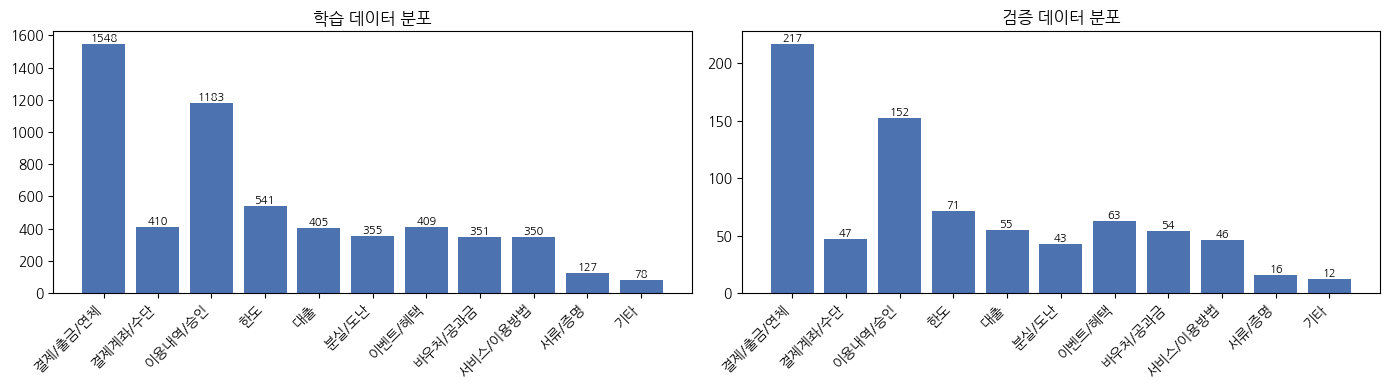

In [ ]:
# 데이터 분포 확인
from collections import Counter

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, dist, title in zip(
    axes,
    [Counter(train_labels), Counter(val_labels)],
    ["학습 데이터 분포", "검증 데이터 분포"]
):
    counts = [dist.get(i, 0) for i in range(len(CLASSES))]

    # x축 위치
    x = range(len(CLASSES))

    # 막대 그래프
    ax.bar(x, counts, color="#4C72B0")

    # 제목 및 축 설정
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(CLASSES, rotation=45, ha="right")

    # 값 표시 (선택 사항)
    for i, v in enumerate(counts):
        ax.text(i, v, str(v), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

---
## 🔤 토크나이저 & 공통 함수

In [ ]:
MODEL_NAME = "klue/roberta-base"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

class ConsultingDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.encodings = tokenizer(
            texts, padding="max_length",
            truncation=True, max_length=max_length, return_tensors="pt"
        )
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels":         self.labels[idx]
        }

print("📝 Dataset 생성 중...")
train_dataset = ConsultingDataset(train_texts, train_labels, tokenizer)
val_dataset   = ConsultingDataset(val_texts,   val_labels,   tokenizer)
train_loader  = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader    = DataLoader(val_dataset,   batch_size=32)
print("✅ 완료!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/546 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/375 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

📝 Dataset 생성 중...
✅ 완료!


In [ ]:
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        optimizer.zero_grad() #기울기 초기화
        loss.backward() #역전파
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        correct += (outputs.logits.argmax(-1) == labels).sum().item()
        total   += labels.size(0)
    return total_loss / len(loader), correct / total

def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["labels"].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds    = outputs.logits.argmax(-1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return correct / total, all_preds, all_labels

def get_probs(model, text, tokenizer, device):
    """단일 텍스트의 softmax 확률 반환"""
    model.eval()
    inputs = tokenizer(
        text, return_tensors="pt",
        padding="max_length", truncation=True, max_length=256
    ).to(device)
    with torch.no_grad():
        logits = model(**inputs).logits
    return torch.softmax(logits, dim=-1)[0].cpu() #확률 반환 함수는?

print("✅ 공통 함수 정의 완료!")

✅ 공통 함수 정의 완료!


---
# 1️⃣ PEFT (LoRA)

## LoRA가 뭔가요?

실습에서 Full Fine-tuning은 전체 파라미터(110M개)를 학습했습니다.  
LoRA는 전체를 건드리지 않고, **아주 작은 행렬 A, B만 추가해서 학습**합니다.

```
Full Fine-tuning:  W_new = W_pretrained + ΔW   (ΔW = 110M 파라미터)
LoRA:              W_new = W_pretrained + A × B  (A, B = 수십만 파라미터만!)
```

**왜 유용한가?**
- GPU 메모리 적게 사용
- 학습 빠름
- 원본 모델 가중치 그대로 → 여러 task용 LoRA를 교체해가며 사용 가능

### LoRA 핵심 파라미터
| 파라미터 | 의미 | 값이 클수록 |
|---|---|---|
| `r` | 저랭크 차원 (행렬 크기) | 표현력 ↑, 파라미터 ↑ |
| `lora_alpha` | 스케일링 계수 | 학습 강도 ↑ |
| `lora_dropout` | 드롭아웃 | 과적합 방지 |

In [ ]:
# peft 라이브러리의 요구사항을 충족하기 위해 torchao를 0.16.0 이상으로 업그레이드합니다.
!pip install --upgrade torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 51.7 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [ ]:
# LoRA 설정
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,    # 분류 task
    r=8,                            # 저랭크 차원
    lora_alpha=16,                  # 스케일링
    lora_dropout=0.1,
    target_modules=["query", "key", "value"],  # attention 레이어에 적용
    bias="none",
)

# 베이스 모델 로드 + LoRA 적용
base_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=len(CLASSES), id2label=id2label, label2id=label2id
)
model_lora = get_peft_model(base_model, lora_config).to(device)

# 학습 파라미터 비교
model_lora.print_trainable_parameters()

model.safetensors:   0%|          | 0.00/443M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: klue/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 1,041,419 || all params: 111,667,990 || trainable%: 0.9326


> 💡 `trainable params`가 전체의 **1~2%** 정도인 걸 확인하세요.  
> Full Fine-tuning(100%)과 비교해서 얼마나 적은지 체감해보세요!

In [ ]:
# LoRA 학습
# 12분 정도 소요되니 돌려놓고 화장실 갔다 오세요...

EPOCHS = 3
LR     = 3e-4  # LoRA는 학습률을 Full Fine-tuning보다 높게 설정

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_lora.parameters()), lr=LR
)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=len(train_loader) * EPOCHS // 10,
    num_training_steps=len(train_loader) * EPOCHS
)

print("🔵 LoRA Fine-tuning 시작!")
history_lora = {"train_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model_lora, train_loader, optimizer, scheduler, device)
    val_acc, _, _         = evaluate(model_lora, val_loader, device)
    history_lora["train_loss"].append(train_loss)
    history_lora["train_acc"].append(train_acc)
    history_lora["val_acc"].append(val_acc)
    print(f"Epoch {epoch+1}/{EPOCHS} | loss={train_loss:.4f} | train={train_acc:.3f} | val={val_acc:.3f}")

print(f"\n✅ LoRA 최종 검증 정확도: {history_lora['val_acc'][-1]:.3f}")

🔵 LoRA Fine-tuning 시작!
Epoch 1/3 | loss=1.3418 | train=0.562 | val=0.758
Epoch 2/3 | loss=0.7983 | train=0.750 | val=0.777
Epoch 3/3 | loss=0.6977 | train=0.782 | val=0.774

✅ LoRA 최종 검증 정확도: 0.774


In [ ]:
import json

# history_lora 저장
with open('history_lora.json', 'w', encoding='utf-8') as f:
    json.dump(history_lora, f, ensure_ascii=False, indent=4)
print("✅ LoRA 학습 기록 'history_lora.json' 저장 완료!")

✅ LoRA 학습 기록 'history_lora.json' 저장 완료!


In [ ]:
# LoRA 모델 저장
LORA_MODEL_PATH = './lora_model'
model_lora.save_pretrained(LORA_MODEL_PATH)
print(f"✅ LoRA 모델이 '{LORA_MODEL_PATH}' 경로에 저장되었습니다!")

✅ LoRA 모델이 './lora_model' 경로에 저장되었습니다!


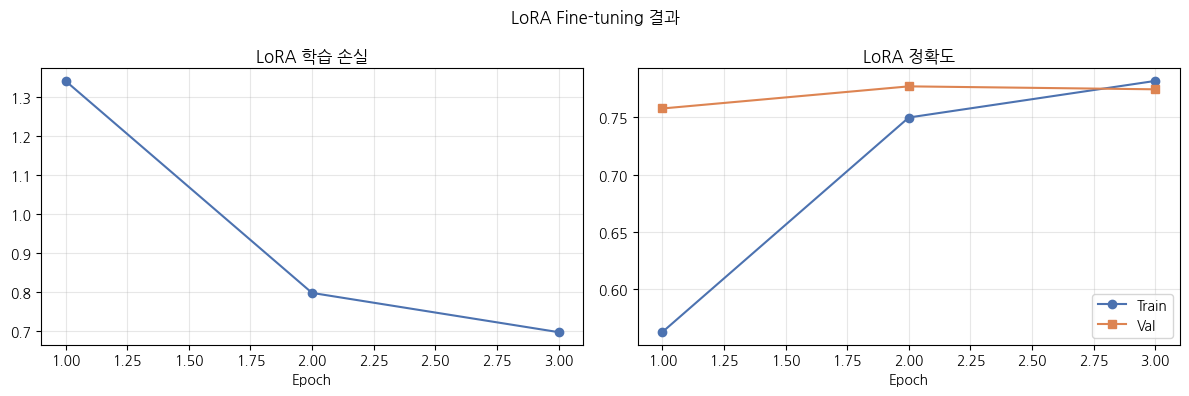

In [ ]:
# LoRA 결과 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, EPOCHS+1), history_lora["train_loss"], marker="o", color="#4C72B0")
axes[0].set_title("LoRA 학습 손실")
axes[0].set_xlabel("Epoch"); axes[0].grid(alpha=0.3)

axes[1].plot(range(1, EPOCHS+1), history_lora["train_acc"], marker="o", label="Train", color="#4C72B0")
axes[1].plot(range(1, EPOCHS+1), history_lora["val_acc"],   marker="s", label="Val",   color="#DD8452")
axes[1].set_title("LoRA 정확도")
axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle("LoRA Fine-tuning 결과", fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# LoRA 클래스별 성능
_, lora_preds, lora_true = evaluate(model_lora, val_loader, device)
print("\n📋 LoRA Classification Report")
print("=" * 60)
print(classification_report(lora_true, lora_preds, target_names=CLASSES, digits=3))


📋 LoRA Classification Report
              precision    recall  f1-score   support

    결제/출금/연체      0.805     0.820     0.813       217
     결제계좌/수단      0.756     0.660     0.705        47
     이용내역/승인      0.750     0.711     0.730       152
          한도      0.896     0.845     0.870        71
          대출      0.672     0.818     0.738        55
       분실/도난      0.976     0.930     0.952        43
      이벤트/혜택      0.785     0.810     0.797        63
     바우처/공과금      0.780     0.852     0.814        54
    서비스/이용방법      0.571     0.522     0.545        46
       서류/증명      0.632     0.750     0.686        16
          기타      0.600     0.500     0.545        12

    accuracy                          0.774       776
   macro avg      0.747     0.747     0.745       776
weighted avg      0.776     0.774     0.774       776



---
# 2️⃣ LLM 프롬프트 엔지니어링

## Gemini API 설정

1. [aistudio.google.com](https://aistudio.google.com) 접속
2. "Get API key" 클릭 → 키 복사
3. 아래 셀에 입력

## ⚠️ API 키를 코드에 직접 입력하지 마세요!
깃허브 퍼블릭 레포에 올라가면 키가 노출됩니다.

**반드시 Colab Secrets를 사용하세요!!!**

1. 왼쪽 사이드바 🔑 아이콘 클릭
2. "새 보안 비밀 추가" 클릭
3. 이름: GEMINI_API_KEY / 값: 발급받은 키 입력
4. 노트북 액세스 토글 ON

## ✏️ Prompt Engineering 실습

아래 **Zero-shot** 프롬프트를 자유롭게 수정하여 Gemini의 분류 성능을 향상시켜 보세요.

<br>

적용 가능한 기법 예시:

**1. Role Prompting**
  
  AI에게 특정 역할을 부여하여 답변의 전문성과 일관성을 높입니다.

    "당신은 하나카드 고객센터에서 상담 분류를 맡고 있는 전문가입니다."

**2. Instruction Prompting**

수행해야 할 작업과 규칙을 구체적으로 지시합니다.

    "고객의 핵심 문의가 뭔지를 파악해서 이를 기준으로 정확히 하나의 카테고리를 선택하세요."

**3. Chain-of-Thought (CoT)**

최종 답을 내기 전에 단계적으로 판단하도록 유도합니다.


    1) 고객의 주요 의도를 파악한다.
    2) 그외 질문은 버린다.
    3) 가장 적절한 카테고리를 선택한다.

**4. Few-shot Examples**

입력과 정답의 예시를 몇 개 제공하여 분류 기준을 학습시키는 방법입니다.


    상담: "결제일을 변경하고 싶어요."
    정답: 결제/출금/연체

**5. Output Format Control**

출력 형식을 엄격하게 지정하여 불필요한 설명을 방지합니다.

    "무조건 카테고리 이름만 출력해."

**6. 추가로 활용할 수 있는 아이디어**
- 클래스 설명 추가

  각 카테고리가 어떤 유형의 상담인지 간단히 설명합니다.

- 시스템 프롬프트 강화

  역할, 맥락, 제약 조건을 명확하게 제시합니다.

<br>

#### **목표**

- Validation Accuracy 향상
- 카테고리별 분류 성능 개선
- 어떤 프롬프트 기법이 가장 효과적인지 비교 분석

<br>

## 🚨반드시 수정해야 합니다! 예시는 빈 깡통이에요! 이거 안 하면 과제 안 한 걸로 간주함!!!!🚨

<br>

In [ ]:
SYSTEM_PROMPT = """

고객센터 상담 내용을 읽고 다음 카테고리 중 하나로 분류하세요.
반드시 카테고리 이름만 출력하세요.

카테고리:
- 결제/출금/연체
- 결제계좌/수단
- 이용내역/승인
- 한도
- 대출
- 분실/도난
- 이벤트/혜택
- 바우처/공과금
- 서비스/이용방법
- 서류/증명
- 기타

예시:
상담 내용: "이번 달 결제일을 15일에서 27일로 변경하고 싶습니다."
분류 결과: 결제/출금/연체

상담 내용: "결제 계좌를 국민은행에서 신한은행으로 바꾸고 싶어요."
분류 결과: 결제계좌/수단

상담 내용: "지난주에 승인된 내역 중에 모르는 결제가 있어요."
분류 결과: 이용내역/승인

상담 내용: "카드 한도를 500만원으로 올릴 수 있을까요?"
분류 결과: 한도

상담 내용: "신용대출 금리가 어떻게 되나요? 대출 신청하고 싶습니다."
분류 결과: 대출

상담 내용: "카드를 잃어버렸는데 바로 정지시켜 주세요."
분류 결과: 분실/도난

상담 내용: "이번 달 포인트 적립 이벤트 참여 방법이 궁금해요."
분류 결과: 이벤트/혜택

상담 내용: "문화누리 바우처로 결제가 안 되는데 확인해 주세요."
분류 결과: 바우처/공과금

상담 내용: "앱에서 간편결제 등록하는 방법을 알려주세요."
분류 결과: 서비스/이용방법

상담 내용: "연말정산용 카드 사용 증명서를 발급받고 싶습니다."
분류 결과: 서류/증명

상담 내용: "상담사 연결이 안 돼서 전화드렸어요."
분류 결과: 기타
"""

def classify_with_gemini(text, system_prompt=SYSTEM_PROMPT): #SYSTEM_PROMPT: 그대로 돌리기 방지용! 반드시 프롬프트 수정하세요.
    """Gemini로 상담 주제 분류"""
    prompt = f"{system_prompt}\n\n상담 내용:\n{text[:500]}\n\n분류 결과:"
    response = gemini.generate_content(prompt)
    result = response.text.strip()
    # 출력에서 가장 유사한 클래스 매칭
    for cls in CLASSES:
        if cls in result:
            return cls
    return "기타"  # 매칭 안 되면 기타

# 테스트
test_text = """
손님: 이번 달 카드 결제일이 15일로 되어 있는데 27일로 변경하고 싶습니다.
상담사: 네, 결제일 변경 후 60일 이내에는 재변경이 어려울 수 있습니다.
손님: 괜찮습니다. 27일로 변경해 주세요.
"""
result = classify_with_gemini(test_text)
print(f"입력: {test_text}")
print(f"분류: {result}")

입력: 
손님: 이번 달 카드 결제일이 15일로 되어 있는데 27일로 변경하고 싶습니다.
상담사: 네, 결제일 변경 후 60일 이내에는 재변경이 어려울 수 있습니다.
손님: 괜찮습니다. 27일로 변경해 주세요.

분류: 결제/출금/연체


> 💡 **프롬프트 엔지니어링 팁**:
> - Few-shot: 각 클래스별 예시 1~2개 추가하면 성능 크게 향상
> - 클래스 설명: "제휴 = SKT, KT 등 통신사 자동납부 관련" 같이 구체적으로
> - 출력 강제: "반드시 위 9개 중 하나만 출력, 다른 말 금지" 명시

### 💸 만약 유료 API 키를 갖고 있다?

`times.sleep(n)`의 n을 낮게, `sample_size`는 11의 배수로 높게 설정해 주시면 더 빠르고 정확한 성능 평가가 가능합니다!

무료로는 10분 걸립니다... (화장실 또 갔다 오세요)

<br>

#### ✔️ 제미나이 API가 코랩에서 호출이 가끔 잘 안 되더라고요...

너무 오랫동안 한 샘플을 평가하고 있다?
  
  세션 재시작 후 공통 함수 정의까지만 하고 다시 LLM 프롬프트 엔지니어링부터 시작해 주세요...

In [ ]:
import time
import random
from collections import defaultdict

def evaluate_gemini(texts, labels, sample_size=200):
    """
    Gemini로 검증 데이터 평가
    - 클래스별 균등 샘플링
    - Gemini 3.1 Flash-Lite 기준 RPM 15 제한 고려 (4.2초 간격)
    - 진행 상황 실시간 출력
    - 오류 발생 시 자동 재시도
    """

    # -----------------------------
    # 1. 클래스별 균등 샘플링
    # -----------------------------
    per_class = max(1, sample_size // len(CLASSES))
    indices_by_class = defaultdict(list)

    for i, label in enumerate(labels):
        indices_by_class[label].append(i)

    sampled_indices = []
    for cls_idx in range(len(CLASSES)):
        idxs = indices_by_class[cls_idx]
        if len(idxs) > 0:
            sampled_indices.extend(
                random.sample(idxs, min(per_class, len(idxs)))
            )

    print(f"📌 평가 샘플 수: {len(sampled_indices)}개")
    print("🟡 Gemini 평가 시작...")
    print("⏳ RPM 15 제한으로 인해 요청 간 4.2초 대기합니다.\n")

    # -----------------------------
    # 2. 예측 수행
    # -----------------------------
    preds, trues = [], []

    for i, idx in enumerate(sampled_indices, start=1):
        # 현재 진행 상황 출력 (버퍼링 방지)
        print(f"[{i}/{len(sampled_indices)}] 요청 중...", flush=True)

        # 최대 3회 재시도
        for attempt in range(3):
            try:
                pred = classify_with_gemini(texts[idx])
                break
            except Exception as e:
                print(f"   ⚠️ 오류 발생 (시도 {attempt+1}/3): {e}", flush=True)

                if attempt == 2:
                    pred = "기타"
                else:
                    # 지수 백오프
                    wait = 5 * (attempt + 1)
                    print(f"   ⏳ {wait}초 후 재시도", flush=True)
                    time.sleep(wait)

        # 예측 결과 저장
        preds.append(label2id.get(pred, label2id["기타"]))
        trues.append(labels[idx])

        # 현재 예측 결과 출력
        print(f"   ✅ 예측: {pred}", flush=True)

        # 중간 정확도 출력
        if i % 10 == 0:
            current_acc = sum(
                p == t for p, t in zip(preds, trues)
            ) / len(preds)
            print(f"   📈 현재 정확도: {current_acc:.3f}\n", flush=True)

        # RPM 15 제한 대응 (60 / 15 = 4초 → 안전하게 4.2초)
        if i < len(sampled_indices):
            time.sleep(4.2)

    # -----------------------------
    # 3. 최종 정확도 계산
    # -----------------------------
    acc = sum(p == t for p, t in zip(preds, trues)) / len(preds)

    print("\n🎉 Gemini 평가 완료!")
    print(f"🏆 최종 정확도: {acc:.3f}")

    return acc, preds, trues


# 실행
# sample_size=55 로 설정하면 11개 클래스 × 5개씩 평가
gemini_acc, gemini_preds, gemini_true = evaluate_gemini(
    val_texts,
    val_labels,
    sample_size=55
)

📌 평가 샘플 수: 55개
🟡 Gemini 평가 시작...
⏳ RPM 15 제한으로 인해 요청 간 4.2초 대기합니다.

[1/55] 요청 중...
   ✅ 예측: 서비스/이용방법
[2/55] 요청 중...
   ✅ 예측: 결제/출금/연체
[3/55] 요청 중...
   ✅ 예측: 결제/출금/연체
[4/55] 요청 중...
   ✅ 예측: 대출
[5/55] 요청 중...
   ✅ 예측: 결제/출금/연체
[6/55] 요청 중...
   ✅ 예측: 이용내역/승인
[7/55] 요청 중...
   ✅ 예측: 이용내역/승인
[8/55] 요청 중...
   ✅ 예측: 결제계좌/수단
[9/55] 요청 중...
   ✅ 예측: 결제계좌/수단
[10/55] 요청 중...
   ✅ 예측: 결제계좌/수단
   📈 현재 정확도: 0.600

[11/55] 요청 중...
   ✅ 예측: 이용내역/승인
[12/55] 요청 중...
   ✅ 예측: 이용내역/승인
[13/55] 요청 중...
   ✅ 예측: 이용내역/승인
[14/55] 요청 중...
   ✅ 예측: 이용내역/승인
[15/55] 요청 중...
   ✅ 예측: 이벤트/혜택
[16/55] 요청 중...
   ✅ 예측: 한도
[17/55] 요청 중...
   ✅ 예측: 한도
[18/55] 요청 중...
   ✅ 예측: 한도
[19/55] 요청 중...
   ✅ 예측: 서비스/이용방법
[20/55] 요청 중...
   ✅ 예측: 한도
   📈 현재 정확도: 0.700

[21/55] 요청 중...
   ✅ 예측: 서류/증명
[22/55] 요청 중...
   ✅ 예측: 대출
[23/55] 요청 중...
   ✅ 예측: 결제/출금/연체
[24/55] 요청 중...
   ✅ 예측: 결제/출금/연체
[25/55] 요청 중...
   ✅ 예측: 서비스/이용방법
[26/55] 요청 중...
   ✅ 예측: 분실/도난
[27/55] 요청 중...
   ✅ 예측: 분실/도난
[28/55] 요청 중...
   ✅ 예측: 분실/도난
[29/55] 

In [ ]:
import json

# Gemini 평가 결과 저장
gemini_results = {
    "gemini_acc": gemini_acc,
    "gemini_preds": gemini_preds,
    "gemini_true": gemini_true
}
with open('gemini_results.json', 'w', encoding='utf-8') as f:
    json.dump(gemini_results, f, ensure_ascii=False, indent=4)
print("✅ Gemini 평가 결과 'gemini_results.json' 저장 완료!")

✅ Gemini 평가 결과 'gemini_results.json' 저장 완료!


In [ ]:
print("\n📋 Gemini Classification Report")
print("=" * 60)
print(classification_report(gemini_true, gemini_preds, target_names=CLASSES, digits=3))


📋 Gemini Classification Report
              precision    recall  f1-score   support

    결제/출금/연체      0.231     0.600     0.333         5
     결제계좌/수단      0.750     0.600     0.667         5
     이용내역/승인      0.667     0.800     0.727         5
          한도      1.000     0.800     0.889         5
          대출      0.500     0.200     0.286         5
       분실/도난      1.000     1.000     1.000         5
      이벤트/혜택      0.800     0.800     0.800         5
     바우처/공과금      1.000     1.000     1.000         5
    서비스/이용방법      0.250     0.400     0.308         5
       서류/증명      0.667     0.400     0.500         5
          기타      0.000     0.000     0.000         5

    accuracy                          0.600        55
   macro avg      0.624     0.600     0.592        55
weighted avg      0.624     0.600     0.592        55



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


---
# 😭 만약 런타임 재시작을 했다면... (안 했다면 바로 비교로 넘어가세요)

In [ ]:
# 만약 런타임을 재시작하여 gemini_acc 등이 초기화된 경우, 여기서 불러올 수 있습니다.
try:
    if 'gemini_acc' not in globals() or 'gemini_preds' not in globals() or 'gemini_true' not in globals():
        with open('gemini_results.json', 'r', encoding='utf-8') as f:
            gemini_results_loaded = json.load(f)
        gemini_acc = gemini_results_loaded["gemini_acc"]
        gemini_preds = gemini_results_loaded["gemini_preds"]
        gemini_true = gemini_results_loaded["gemini_true"]
        print("✅ Gemini 평가 결과 'gemini_results.json' 불러오기 완료!")
except FileNotFoundError:
    print("⚠️ 'gemini_results.json' 파일을 찾을 수 없습니다. Gemini 평가를 먼저 실행해주세요.")
except Exception as e:
    print(f"⚠️ Gemini 평가 결과 불러오기 중 오류 발생: {e}")

In [ ]:
# 만약 런타임을 재시작하여 history_lora가 초기화된 경우, 여기서 불러올 수 있습니다.
try:
    if 'history_lora' not in globals():
        with open('history_lora.json', 'r', encoding='utf-8') as f:
            history_lora = json.load(f)
        print("✅ LoRA 학습 기록 'history_lora.json' 불러오기 완료!")
except FileNotFoundError:
    print("⚠️ 'history_lora.json' 파일을 찾을 수 없습니다. LoRA 학습을 먼저 실행해주세요.")
except Exception as e:
    print(f"⚠️ history_lora 불러오기 중 오류 발생: {e}")

In [ ]:
from peft import PeftModel, PeftConfig
from transformers import AutoModelForSequenceClassification

# LORA_MODEL_PATH 정의를 다시 추가합니다.
LORA_MODEL_PATH = './lora_model'

# 런타임 재시작 시, 베이스 모델 로드 후 LoRA 가중치 로드
# 먼저 베이스 모델을 불러옵니다.
base_model_for_loading = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=len(CLASSES), id2label=id2label, label2id=label2id
)

# 저장된 LoRA 가중치를 베이스 모델에 적용합니다.
model_lora = PeftModel.from_pretrained(base_model_for_loading, LORA_MODEL_PATH)
model_lora = model_lora.to(device)

print("✅ LoRA 모델이 성공적으로 불러와졌습니다!")

# 불러온 모델로 평가를 진행해볼 수 있습니다.
# loaded_val_acc, _, _ = evaluate(loaded_model_lora, val_loader, device)
# print(f"불러온 LoRA 모델의 검증 정확도: {loaded_val_acc:.3f}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: klue/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ LoRA 모델이 성공적으로 불러와졌습니다!


# 📊 비교: LoRA vs 프롬프트 엔지니어링

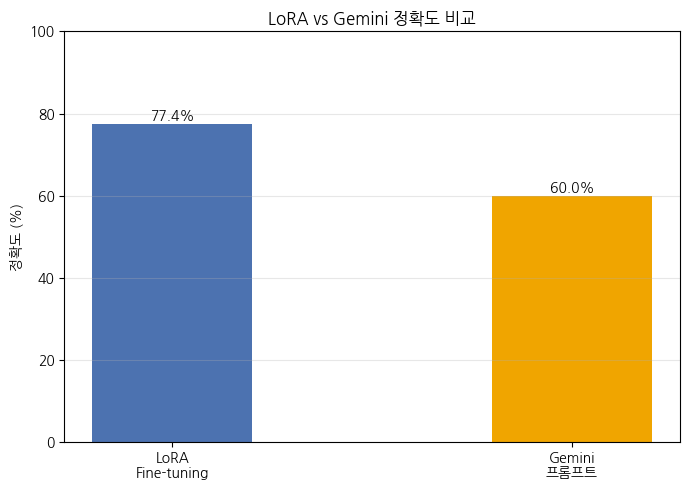


LoRA:   77.4%
Gemini: 60.0%


In [ ]:
# 정확도 비교
methods = ["LoRA\nFine-tuning", "Gemini\n프롬프트"]
accs    = [history_lora["val_acc"][-1], gemini_acc]
colors  = ["#4C72B0", "#F0A500"]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(methods, [a * 100 for a in accs], color=colors, width=0.4)
ax.set_ylim(0, 100)
ax.set_ylabel("정확도 (%)")
ax.set_title("LoRA vs Gemini 정확도 비교", fontweight="bold")
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{acc*100:.1f}%", ha="center", fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nLoRA:   {accs[0]*100:.1f}%")
print(f"Gemini: {accs[1]*100:.1f}%")

In [ ]:
test_cases = [
   "상담사: 상담원 ▲▲▲입니다.\n손님: 아 예, 수고하십니다 조금 전에\n상담사: 네.\n손님: 어 그 분실 신고를 해 가지고 재발급을 했는데\n상담사: 네.\n손님: 혹시 그 이게 인자 그 전산상에는 쓴 게 없는데 혹시나 한 번 더 사용내역 있는지 한번 확인 좀 부탁드릴게요.\n상담사: 네, 마지막 사용 내역 확인해 드릴 거고요. 먼저 전화주신 손님 성함이 ▲▲▲ 님 본인 맞으십니까?\n손님: 네.\n상담사: 네, 해당 카드 최종 이용 내역은 ▲▲월 ▲▲일 오후 ▲▲시 ▲▲분 석봉 토스트 ▲▲원이 마지막이세요.\n손님: 아 거기가 마지막이에요?\n상담사: 네, 그 사용 건이 마지막 사용 건으로 확인되세요.\n손님: 아 네 네 그러면 그 만약에 예를 들어서 중간에 만약에 카드를 찾으면은\n손님: 어떻게 재발급 신청을 했는데 제가\n상담사: 네, 어.\n상담사: 네 오늘 오후 10시 이전까지는 재발급 취소 철회가 가능한데요. 오늘 오후 10시 이후부터는 카드 발급 진행이 돼서 기존 카드 찾으시더라도 그냥 잘게 잘라 폐기해 주시면 됩니다.\n손님: 네 네.\n손님: 아 10시 이후로\n상담사: 네.\n손님: 아 그러면 이거 재발급 되면은\n손님: 발급 받은 카드는 혹시 언제 받아 볼 수 있나요?\n상담사: 네, 평일 기준 3일 내로 받아 보실 겁니다.\n손님: 아 그러면 오늘 이렇게 하면 내일\n손님: 내일 내일 받을 수 있나요, 그러면?\n상담사: 네, 평일 기준 3일 안으로 받아볼 수 있는 거예요.\n손님: 아 3일 안으로\n상담사: 네.\n손님: ▲▲일 이면 가능하겠네요. 예, 알겠습니다.\n상담사: 네, 감사합니다. 상담원 ▲▲▲이었습니다.\n손님: 그리고 혹시\n손님: 그리고 여기 제가 여기 아마 그 저 자동 이체를 해 놓은 건이 있는지 확인할 수 있을까?\n상담사: 네, 저희가 승인 내역으로 확인했는데요. 승인 내역으로는 저희 확인되는 게 없는데요. 다만 저희가 말씀 드릴 수 있는 내용은요.\n손님: 네.\n상담사: 네, 그 가맹점이나 그 자동 납부 처리 시점에 따라서 금액 그 저희가 확인이 안 되실 수가 있어요. 일단은 저희가 최근 삼 개월 동안\n상담사: 따로 금액 자동 이체 결제 건으로 확인되지는 않으세요. 다만 그 승인되는 기간이 뭐 삼 개월 이거나 아직 승인이 되지 않은 거래 건은 저희 확인은 어렵습니다.\n손님: 그 정기적으로 그 그 그러니까 정기적으로 나가서 결제가 되는 게 혹시 있나요, 그러면?\n상담사: 네, 손님\n손님: 네, 예 정기적으로 매달 그 이렇게 금액이 더 나가는 금액있잖아요?\n손님: 그\n상담사: 어떤 말씀이시죠? 그 정기적으로 나가는 금액이 있으신데 그 다음을 말씀부탁드릴게요.\n손님: 네, 인제 제 카드로 이렇게 정기적으로 결제가 되는 내용이 있는지\n상담사: 그러니까 최근 삼 개월 동안으로 확인되는 건 없으세요. 그런데 없다라고는 확답드리기는 어려워요. 왜냐하면 아직 결제가 안 된 결제 건이 있거나 뭐 일 년 단위로 결제되는 결제 건이 있기 때문에 그 부분은 저희가 확인이 어렵습니다.\n손님: 여보세요?\n손님: 아\n손님: 일단 예 알겠습니다, 일단.\n상담사: 네, 감사합니다. 상담사 ▲▲▲이었습니다.\n손님: 네, 수고하세요.\n\t                                        \n\t                                        "
, "아이 소득공제 뭐시기를 받아야 한다니께는",
   "저... 그 엊그제 카드를 잃어버렸는데 정지시켜주세요",
   "상담사: 상담원 ▲▲▲입니다.\n손님: 예, 안녕하세요?\n상담사: 예, 안녕하세요?\n손님: 아 예. 그 제가 갖고 있는 그 ▲▲▲마일 포인트를 그 ▲▲마일로 전환 좀 할려구요.\n상담사: 저희 ▲▲마일리지 같은 경우에는 잠시만 기다려주시겠습니까? ▲▲마일로 전환이 가능한지 확인해보겠습니다.\n손님: 네, 가능 가능해요. 예, 가능했었어요. 제가 몇 번 했었거든요.\n상담사: 아 그러세요? ▲▲▲ 고객님 본인 되시죠?\n손님: 네.\n상담사: 예, 소중한 정보 확인 감사합니.다 네, 그럼 ▲▲▲마일 현재 가지고 계신 마일리지 같은 경우에는 ▲▲▲▲▲▲▲마일리지 있으신데 이거 전부 ▲▲마일리지로\n손님: 아니 아니요. 전부 아니고요. ▲▲▲▲▲▲마일리요 ▲▲▲▲ 마일리지 좀 전환 부탁드리겠습니다.\n상담사: ▲▲▲▲▲이요.\n손님: 예.\n상담사: 네 네, 제가 확인해볼 텐데 잠시만 기다려주십니까?\n손님: 예,\n상담사: 어 기다려 주셔서 감사합니다.\n상담사: 아 저희가 고객님 이거 그 대한항공이나 아시아나 가 아니라 ▲▲ 마일리지로 변경\n손님: 아 잠시만요. 잠시만요.\n상담사: 네.\n손님: 제가 갖고 있는 카드가 지금 헷갈려가지고\n상담사: 네.\n손님: 어\n손님: 잠시만요.\n손님: 아 ▲▲마일 맞아요. 네,▲▲마일이요.\n상담사: 아 그러세요? 잠시만 기다려주십니까?\n손님: 네.\n상담사: 예.\n상담사: 네, 고객님 기다려주셔서 감사합니다. 그럼 ▲▲▲▲▲ 마일리지\n손님: ▲▲▲▲▲이요. ▲▲▲▲▲이요.\n상담사: 아 ▲▲▲원\n상담사: 아 ▲▲▲▲▲▲▲ 마일리지 ▲▲▲마일에서 ▲▲마일로 해 드리고 마일리지 전환 취소는 익 영업일까지 취소 가능하시며\n상담사: 혹시라도 고객님께서\n상담사: 어 이게\n상담사: 이제\n상담사: 그 다음에 신용 카드 계약 종료 또는 제휴 계약 종료 시까지 이제 종료되면 이제 상계 개인 정보에 대한 동의는 이제 ▲▲▲마일 전환을 위해 필수적이므로 위 사항에 동의할 수 있어야지만 전환이 가능한데 전환에 동의하시겠습니까?\n손님: 네, 동의합니다, ▲▲마일로 전환 부탁드립니다.\n상담사: 아 네.\n상담사: 예, 그럼 전환 신청은\n손님: ▲▲▲▲▲이요. 네.\n상담사: 네, 전환 신청 우선 완료되어가지고 이제 전환신청 같은 경우 기간이 조금 소요되니까 참고 부탁드리도록 하겠습니다.\n손님: 예, 알겠습니다. 고맙습니다.\n상담사: 상담사 ▲▲▲이었습니다\n손님: 예, 고맙습니다.\n상담사: 네, 감사합니다."
]

print("=" * 65)
print(f"{'입력':30s} {'LoRA':20s} {'Gemini':20s}")
print("=" * 65)
for text in test_cases:
    # LoRA 예측
    probs = get_probs(model_lora, text, tokenizer, device)
    lora_pred = id2label[probs.argmax().item()]

    # Gemini 예측
    gemini_pred = classify_with_gemini(text)

    match = "✅" if lora_pred == gemini_pred else "❌"
    print(f"{text[:28]:30s} {lora_pred[:18]:20s} {gemini_pred[:18]:20s} {match}")
print("=" * 65)

입력                             LoRA                 Gemini              
상담사: 상담원 ▲▲▲입니다.
손님: 아 예, 수고   이용내역/승인              이용내역/승인              ✅
아이 소득공제 뭐시기를 받아야 한다니께는         이벤트/혜택               서류/증명                ❌
저... 그 엊그제 카드를 잃어버렸는데 정지시켜주세   분실/도난                분실/도난                ✅
상담사: 상담원 ▲▲▲입니다.
손님: 예, 안녕하세   이벤트/혜택               이벤트/혜택               ✅


## ✏️ 비교 분석 (아래 질문에 직접 답변을 작성해 주세요!)


1. 어떤 방법의 정확도가 더 높았나요? 예상했던 결과인가요? <br>
답: ***Lora가 더 높앗음. 계산을 더 빠르게 한다고 해서 정확도가 낮을 것이라 생각했는데 그렇지 않아서 신기했습니당***

2. 두 방법이 서로 다르게 예측한 케이스가 있었나요?
   어떤 방법이 맞았고 왜 그랬을까요?  <br>
답: ***"아이 소득공제 뭐시기를 받아야 한다니께는" Gemini가 맞았습니다.
Loㄱㅁ가 틀린 이유는 "소득공제"를 다르게 해석했을 것으로 보임.이는 패턴에 의존해서 맥락을 혼동한 반면, Gemini는 LLM의 언어 이해 능력으로 더 정확하게 해석한 케이스라 생각합니다.***

3. LoRA vs Gemini(프롬프트 엔지니어링)를 현업에서 선택한다면 어떤 기준으로 결정할까요?
   (정확도 외에 비용, 속도, 유지보수 등도 고려해보세요) <br>
답: ***정확도나 비용, 속도 측면에서 Lora가 더 좋을 것 같습니다.!***

> 짧은 테스트 문장에선 오히려 제미나이의 성능이 더 좋은 걸 알 수 있습니다. 그러나 실제 데이터로 구성된 테스트 문장에서는 인증 절차, 반복 표현, 장문의 대화가 포함되어 있어 도메인 특화 데이터를 학습한 LoRA 모델이 더 좋은 성능을 보여 줍니다. 이는 도메인 특화 파인튜닝 모델의 강점이죠.


그러나... 아직 정확도가 77%잖아요? 분류를 못 하는 게 있다는 겁니다.

---
# 3️⃣ 혼합: 확신도 기반 라우팅

## 아이디어

LoRA 모델이 확신하는 케이스는 빠르게 처리하고,  
**확신도가 낮을 때만 Gemini에게 위임**합니다.

```
입력 텍스트
    ↓
LoRA 모델 (빠름, 저렴)
    ├── 확신도 ≥ threshold → LoRA 결과 사용 ✅
    └── 확신도 < threshold → Gemini에게 위임 🔀
                                ↓
                           Gemini 결과 사용
```

이게 실무에서 **"LLM-as-judge"** 또는 **"fallback 패턴"** 이라고 불려요.  
빠른 모델로 대부분 처리하고, 어려운 케이스만 강력한 모델에 넘기는 방식이에요.

### ✏️ threshold를 바꿔가며 실험해보세요!

In [ ]:
def classify_hybrid(text, lora_model, threshold):
    """
    확신도 기반 혼합 분류
    - LoRA 확신도 >= threshold: LoRA 결과 사용
    - LoRA 확신도 < threshold: Gemini에게 위임
    """
    probs     = get_probs(lora_model, text, tokenizer, device)
    max_prob  = probs.max().item()
    lora_pred = id2label[probs.argmax().item()]

    if max_prob >= threshold:
        return lora_pred, "LoRA", max_prob
    else:
        gemini_pred = classify_with_gemini(text)
        return gemini_pred, "Gemini", max_prob


# 동작 확인
test_cases = [
   "상담사: 상담원 ▲▲▲입니다.\n손님: 아 예, 수고하십니다 조금 전에\n상담사: 네.\n손님: 어 그 분실 신고를 해 가지고 재발급을 했는데\n상담사: 네.\n손님: 혹시 그 이게 인자 그 전산상에는 쓴 게 없는데 혹시나 한 번 더 사용내역 있는지 한번 확인 좀 부탁드릴게요.\n상담사: 네, 마지막 사용 내역 확인해 드릴 거고요. 먼저 전화주신 손님 성함이 ▲▲▲ 님 본인 맞으십니까?\n손님: 네.\n상담사: 네, 해당 카드 최종 이용 내역은 ▲▲월 ▲▲일 오후 ▲▲시 ▲▲분 석봉 토스트 ▲▲원이 마지막이세요.\n손님: 아 거기가 마지막이에요?\n상담사: 네, 그 사용 건이 마지막 사용 건으로 확인되세요.\n손님: 아 네 네 그러면 그 만약에 예를 들어서 중간에 만약에 카드를 찾으면은\n손님: 어떻게 재발급 신청을 했는데 제가\n상담사: 네, 어.\n상담사: 네 오늘 오후 10시 이전까지는 재발급 취소 철회가 가능한데요. 오늘 오후 10시 이후부터는 카드 발급 진행이 돼서 기존 카드 찾으시더라도 그냥 잘게 잘라 폐기해 주시면 됩니다.\n손님: 네 네.\n손님: 아 10시 이후로\n상담사: 네.\n손님: 아 그러면 이거 재발급 되면은\n손님: 발급 받은 카드는 혹시 언제 받아 볼 수 있나요?\n상담사: 네, 평일 기준 3일 내로 받아 보실 겁니다.\n손님: 아 그러면 오늘 이렇게 하면 내일\n손님: 내일 내일 받을 수 있나요, 그러면?\n상담사: 네, 평일 기준 3일 안으로 받아볼 수 있는 거예요.\n손님: 아 3일 안으로\n상담사: 네.\n손님: ▲▲일 이면 가능하겠네요. 예, 알겠습니다.\n상담사: 네, 감사합니다. 상담원 ▲▲▲이었습니다.\n손님: 그리고 혹시\n손님: 그리고 여기 제가 여기 아마 그 저 자동 이체를 해 놓은 건이 있는지 확인할 수 있을까?\n상담사: 네, 저희가 승인 내역으로 확인했는데요. 승인 내역으로는 저희 확인되는 게 없는데요. 다만 저희가 말씀 드릴 수 있는 내용은요.\n손님: 네.\n상담사: 네, 그 가맹점이나 그 자동 납부 처리 시점에 따라서 금액 그 저희가 확인이 안 되실 수가 있어요. 일단은 저희가 최근 삼 개월 동안\n상담사: 따로 금액 자동 이체 결제 건으로 확인되지는 않으세요. 다만 그 승인되는 기간이 뭐 삼 개월 이거나 아직 승인이 되지 않은 거래 건은 저희 확인은 어렵습니다.\n손님: 그 정기적으로 그 그 그러니까 정기적으로 나가서 결제가 되는 게 혹시 있나요, 그러면?\n상담사: 네, 손님\n손님: 네, 예 정기적으로 매달 그 이렇게 금액이 더 나가는 금액있잖아요?\n손님: 그\n상담사: 어떤 말씀이시죠? 그 정기적으로 나가는 금액이 있으신데 그 다음을 말씀부탁드릴게요.\n손님: 네, 인제 제 카드로 이렇게 정기적으로 결제가 되는 내용이 있는지\n상담사: 그러니까 최근 삼 개월 동안으로 확인되는 건 없으세요. 그런데 없다라고는 확답드리기는 어려워요. 왜냐하면 아직 결제가 안 된 결제 건이 있거나 뭐 일 년 단위로 결제되는 결제 건이 있기 때문에 그 부분은 저희가 확인이 어렵습니다.\n손님: 여보세요?\n손님: 아\n손님: 일단 예 알겠습니다, 일단.\n상담사: 네, 감사합니다. 상담사 ▲▲▲이었습니다.\n손님: 네, 수고하세요.\n\t                                        \n\t                                        "
, "아이 소득공제 뭐시기를 받아야 한다니께는",
   "저... 그 엊그제 카드를 잃어버렸는데 정지시켜주세요",
   "상담사: 상담원 ▲▲▲입니다. 무엇을 도와드릴까요?\n손님: 예 예 그거 저 ▲▲카드 거기에서 우리 그 정수기 요금이 그 빠져나가거든요?\n상담사: 예.\n상담사: 네.\n손님: 예, 그런데 제가 방금 분실 신고를 했는데\n상담사: 예.\n손님: 새로 재발급을 했거든요.\n상담사: 음 그러시군요.\n손님: 예.\n상담사: 예 어 혹시 예.\n손님: 그랬는데 그거 요금이 그 뭐 분실 신고를 했는데 어떻게 해야 될까요?\n상담사: 아 예. 제가 정보부터 확인하고 안내 도와드리겠습니다. 지금 연락 주신 손님 본인 성함 말씀해주시겠습니까?\n손님: 예 예.\n상담사: 예, ▲▲▲ 님 본인 맞으신가요?\n손님: 예 예.\n상담사: 예, 확인 감사합니다. 지금 확인해보니 그 현대 렌탈 케어라고 예 지금 이용하고 계신 걸로 확인되시는데 여기 그 자동 이체 승계가 되는지 물어보시는 건가요?\n손님: 예.\n상담사: 어 예, 제가 확인해보도록 하겠습니다. 잠시만 기다려주시겠습니까?\n손님: 네.\n상담사: 예, 손님 기다려 주셔서 감사합니다. 예 지금 확인해보니 해당 가맹점은 자동 승계 가맹점은 아니시기 때문에 예 그 새 카드 받으시면은 여기 현대 렌탈 케어로 전화하셔가지고\n손님: 예.\n상담사: 자동 이체 새로 신청해 주셔야 되세요.\n손님: 아 새로 신청을 할까요?\n상담사: 네.\n손님: 그러면 저 저 현대로 전화해가지고\n상담사: 예, 현대 렌탈 케어로 연락하셔가지고 새 카드 번호 말씀해주시면 되십니다.\n손님: 아 그래요?\n상담사: 네.\n손님: 아 알겠습니다. 고맙습니다.\n상담사: 네, 감사합니다. 상담사 ▲▲▲이었습니다 \n손님: 네.",
   "손님: 네.\n상담사: 상담원 ▲▲▲입니다.\n손님: 예, 수고하십니다.\n상담사: 안녕하세요?\n손님: 예, 제가 ▲▲월 ▲▲카드 결제일인데요.\n상담사: 네.\n손님: 그 뭐야 그 소액 소액결제 금액만 그 지금 현재 ▲▲은행 계좌에서 즉시 입금됐을 텐데 전화 안 해도 되는지 모르겠어요.\n상담사: 아 네, 혹시 먼저 본인확인을 위해서 생년월일과 휴대폰 번호 말씀 부탁드립니다.\n손님: ▲▲년 ▲▲월 ▲▲일\n상담사: 네.\n손님: ▲▲▲ 어 뭐야 ▲▲원인가 뭐 ▲▲▲▲▲▲▲▲\n상담사: 네, 그리고 전화주신 손님 본인 성함이 어떻게 되세요?\n손님: ▲▲▲요.\n상담사: 마지막으로 ▲▲카드에 연결되어 있는 결제 은행은 어디 은행이세요?\n손님: 예, ▲▲은행인데요.\n상담사: 네, 확인되었고요.\n상담사: 그렇습니다. 말씀하신 대로 네.\n상담사: 지금 ▲▲월 ▲▲일 날 이제 가상계좌를 통해서 ▲▲▲원 납부하셨고 나머지 이제\n손님: 예.\n상담사: 잔액이 만큼 그 ▲▲▲▲▲▲▲원 이제 금액 청구되었거든요. 그래가지고\n손님: 네.\n상담사: 요청하신 대로 만약에 다음 달로 이월하고 싶으시면요.\n손님: 예.\n상담사: 오늘 하루 동안은 꼭 잔고 비워 두셔야 되는 점만 참고해 주시면요.\n손님: 예.\n상담사: 이제 다음 달로 자동으로 이월됩니다.\n손님: 예 예 고맙습니다. 예.\n상담사: 그 이제 만약에 그 창구 있는 금액 더 출금된 금액은 나중에 환불 불가능하니까요. 오늘 하루 동안은 꼭 잔고 비워 두셔야 되는 점만 부탁드립니다.\n손님: 예.\n상담사: 네, 상담사 ▲▲▲이었습니다.\n손님: 예.\n상담사: 네, 감사합니다.\n상담사: 예\n\t                                        ",
   "상담사: 상담원 ▲▲▲입니다.\n손님: 예, 안녕하세요?\n상담사: 예, 안녕하세요?\n손님: 아 예. 그 제가 갖고 있는 그 ▲▲▲마일 포인트를 그 ▲▲마일로 전환 좀 할려구요.\n상담사: 저희 ▲▲마일리지 같은 경우에는 잠시만 기다려주시겠습니까? ▲▲마일로 전환이 가능한지 확인해보겠습니다.\n손님: 네, 가능 가능해요. 예, 가능했었어요. 제가 몇 번 했었거든요.\n상담사: 아 그러세요? ▲▲▲ 고객님 본인 되시죠?\n손님: 네.\n상담사: 예, 소중한 정보 확인 감사합니.다 네, 그럼 ▲▲▲마일 현재 가지고 계신 마일리지 같은 경우에는 ▲▲▲▲▲▲▲마일리지 있으신데 이거 전부 ▲▲마일리지로\n손님: 아니 아니요. 전부 아니고요. ▲▲▲▲▲▲마일리요 ▲▲▲▲ 마일리지 좀 전환 부탁드리겠습니다.\n상담사: ▲▲▲▲▲이요.\n손님: 예.\n상담사: 네 네, 제가 확인해볼 텐데 잠시만 기다려주십니까?\n손님: 예,\n상담사: 어 기다려 주셔서 감사합니다.\n상담사: 아 저희가 고객님 이거 그 대한항공이나 아시아나 가 아니라 ▲▲ 마일리지로 변경\n손님: 아 잠시만요. 잠시만요.\n상담사: 네.\n손님: 제가 갖고 있는 카드가 지금 헷갈려가지고\n상담사: 네.\n손님: 어\n손님: 잠시만요.\n손님: 아 ▲▲마일 맞아요. 네,▲▲마일이요.\n상담사: 아 그러세요? 잠시만 기다려주십니까?\n손님: 네.\n상담사: 예.\n상담사: 네, 고객님 기다려주셔서 감사합니다. 그럼 ▲▲▲▲▲ 마일리지\n손님: ▲▲▲▲▲이요. ▲▲▲▲▲이요.\n상담사: 아 ▲▲▲원\n상담사: 아 ▲▲▲▲▲▲▲ 마일리지 ▲▲▲마일에서 ▲▲마일로 해 드리고 마일리지 전환 취소는 익 영업일까지 취소 가능하시며\n상담사: 혹시라도 고객님께서\n상담사: 어 이게\n상담사: 이제\n상담사: 그 다음에 신용 카드 계약 종료 또는 제휴 계약 종료 시까지 이제 종료되면 이제 상계 개인 정보에 대한 동의는 이제 ▲▲▲마일 전환을 위해 필수적이므로 위 사항에 동의할 수 있어야지만 전환이 가능한데 전환에 동의하시겠습니까?\n손님: 네, 동의합니다, ▲▲마일로 전환 부탁드립니다.\n상담사: 아 네.\n상담사: 예, 그럼 전환 신청은\n손님: ▲▲▲▲▲이요. 네.\n상담사: 네, 전환 신청 우선 완료되어가지고 이제 전환신청 같은 경우 기간이 조금 소요되니까 참고 부탁드리도록 하겠습니다.\n손님: 예, 알겠습니다. 고맙습니다.\n상담사: 상담사 ▲▲▲이었습니다\n손님: 예, 고맙습니다.\n상담사: 네, 감사합니다."
]

print(f"{'입력':30s} {'결과':20s} {'담당':8s} {'확신도':8s}")
print("=" * 70)
for text in test_cases:
    pred, source, conf = classify_hybrid(text, model_lora, threshold=0.5)
    print(f"{text[:28]:30s} {pred[:18]:20s} {source:8s} {conf:.3f}")

입력                             결과                   담당       확신도     
상담사: 상담원 ▲▲▲입니다.
손님: 아 예, 수고   이용내역/승인              Gemini   0.475
아이 소득공제 뭐시기를 받아야 한다니께는         서류/증명                Gemini   0.379
저... 그 엊그제 카드를 잃어버렸는데 정지시켜주세   분실/도난                LoRA     0.988
상담사: 상담원 ▲▲▲입니다. 무엇을 도와드릴까요?   이용내역/승인              LoRA     0.579
손님: 네.
상담사: 상담원 ▲▲▲입니다.
손님:    결제/출금/연체             Gemini   0.452
상담사: 상담원 ▲▲▲입니다.
손님: 예, 안녕하세   이벤트/혜택               LoRA     0.862


#### ✔️ 또 너무 오래 돌고 중간 보고가 안 나온다?

런타임 재시작 후 공통 함수까지 정의, gemini api 설정 및 프롬프트 입력, 런타임 재시작했다면?에 해당하는 셀 세 개 실행하고 와 주시면 됩니다..........

In [ ]:
import time

def evaluate_hybrid(texts, labels, lora_model, threshold, sample_size=200):
    """혼합 방식 성능 평가"""
    from collections import defaultdict
    import random

    per_class = sample_size // len(CLASSES)
    indices_by_class = defaultdict(list)
    for i, l in enumerate(labels):
        indices_by_class[l].append(i)

    sampled_indices = []
    for cls_idx in range(len(CLASSES)):
        idxs = indices_by_class[cls_idx]
        sampled_indices.extend(random.sample(idxs, min(per_class, len(idxs))))

    preds, trues = [], []
    lora_count, gemini_count = 0, 0

    for idx in sampled_indices:
        pred, source, _ = classify_hybrid(texts[idx], lora_model, threshold)
        preds.append(label2id.get(pred, 10))
        trues.append(labels[idx])
        if source == "LoRA":
            lora_count += 1
        else:
            gemini_count += 1
            time.sleep(2)

        if (len(preds) % 10) == 0:
          print(f"{len(preds)}/{len(sampled_indices)} 완료 "
          f"(LoRA {lora_count}, Gemini {gemini_count})",
          flush=True)

    acc = sum(p == t for p, t in zip(preds, trues)) / len(preds)
    print(f"  LoRA 처리: {lora_count}건 ({lora_count/len(sampled_indices)*100:.1f}%)")
    print(f"  Gemini 처리: {gemini_count}건 ({gemini_count/len(sampled_indices)*100:.1f}%)")
    return acc, preds, trues


# threshold 0.5로 평가
print("🔴 혼합 방식 평가 시작...")
hybrid_acc, hybrid_preds, hybrid_true = evaluate_hybrid(
    val_texts, val_labels, model_lora, threshold=0.7
)
print(f"\n혼합 정확도: {hybrid_acc:.3f}")

🔴 혼합 방식 평가 시작...
10/190 완료 (LoRA 9, Gemini 1)
20/190 완료 (LoRA 16, Gemini 4)
30/190 완료 (LoRA 23, Gemini 7)
40/190 완료 (LoRA 32, Gemini 8)
50/190 완료 (LoRA 35, Gemini 15)
60/190 완료 (LoRA 45, Gemini 15)
70/190 완료 (LoRA 54, Gemini 16)
80/190 완료 (LoRA 63, Gemini 17)
90/190 완료 (LoRA 70, Gemini 20)
100/190 완료 (LoRA 80, Gemini 20)
110/190 완료 (LoRA 89, Gemini 21)
120/190 완료 (LoRA 98, Gemini 22)
130/190 완료 (LoRA 106, Gemini 24)
140/190 완료 (LoRA 115, Gemini 25)
150/190 완료 (LoRA 122, Gemini 28)
160/190 완료 (LoRA 128, Gemini 32)
170/190 완료 (LoRA 133, Gemini 37)
180/190 완료 (LoRA 141, Gemini 39)
190/190 완료 (LoRA 146, Gemini 44)
  LoRA 처리: 146건 (76.8%)
  Gemini 처리: 44건 (23.2%)

혼합 정확도: 0.742


### ✏️ 혼합 방식 분석 (아래 질문에 직접 답변을 작성해 주세요!)

1. 어떤 threshold를 선택했고, 그 이유는 뭔가요?<br>
답: ***0.7, 0.7 이상에만 Lora를 사용하고, 아닌 경우에는 Gemini에 던지는 것이 가장 좋았기 때문. 0.3이면 틀린 예측까지 그대로 사용하게 되고, 0.9이면 대부분 제미나이로 넘겨져 비용이 크게 증가하기 때문.***

2. 혼합 방식이 LoRA 단독, Gemini 단독보다 나은가요?
   예상과 다른 결과가 나왔다면 이유가 뭘까요?<br>
답: ***혼합이 Lora 보다 정확도가 높고, Gemini 단독과는 비슷한 정확도이나 API 호출 횟수를 줄일 수 있었다. Lora가 확신하는 쉬운 케이스는 빠르고 저렴하게 처리하고, 어려운 케이스만 Gemini에 넘기므로 비용 대비 성능이 가장 효율적***

# 4️⃣ 세 가지 방식 비교 (정확도를 채워 주세요!)

| 방식 | 정확도 | 학습 필요 | 비용 | 특징 |
|---|---|---|---|---------|
|**LoRA** | (77.7) | ✅ | GPU | 파라미터 1~2%만 학습 |
|**Gemini** | (52.7) | ❌ | API 비용 | 프롬프트 설계가 핵심 |
| **혼합** | (74.2) | ✅ | 혼합 | 현실적인 프로덕션 패턴 |

이 섹션의 분석은 **여러분이 설계한 프롬프트**에 따라
결과가 완전히 달라질 수 있습니다.

<br>

## **🤔 혼합 방식이 효과적이려면?**

혼합의 아이디어는 직관적입니다.

`LoRA가 확신하지 못하는 케이스 → 더 강한 Gemini에게 위임 → 전체 성능 향상`

하지만 이게 항상 성립하지는 않습니다.

<br>

LoRA가 threshold를 넘지 못해서 Gemini에 넘긴 케이스는
모델이 헷갈리는 **경계선 케이스**입니다.

예를 들어,
- "결제 계좌 변경하고 싶어요" → 결제/출금/연체? 결제계좌/수단?
- "이벤트로 나온 바우처 문의드려요" → 이벤트/혜택? 바우처/공과금?
<br>

이런 케이스는 LoRA도 어렵고, **프롬프트가 약하면** Gemini도 어렵습니다.
반대로 **프롬프트가 강하면** Gemini가 이런 경계선을 더 잘 처리할 수도 있습니다.

## **📔 가능한 시나리오별 해석**

**시나리오 A: 혼합 > LoRA** ✅
- LoRA의 도메인 지식 + Gemini의 추론력이 잘 결합된 케이스
- 프롬프트가 경계선 케이스를 잘 커버하고 있을 가능성이 높음

**시나리오 B: LoRA > 혼합** ⚠️
- LoRA가 확신 못 하는 케이스를 Gemini도 못 맞추는 상황
- 프롬프트 개선 여지가 있음
- Few-shot 예시를 경계선 케이스 위주로 추가해보세요!

**시나리오 C: Gemini > 혼합 > LoRA** 🤔
- 프롬프트가 강력한데 threshold가 너무 높아서 Gemini를 충분히 못 쓰는 상황
- threshold를 낮춰서 Gemini 의존도를 높이면 더 좋아질 수 있음


<br>

#### 이외 개선 전략

1. **threshold 조정**: 낮추면 Gemini 의존도 높아짐 → 반드시 좋아지진 않음
2. **Few-shot 강화**: Gemini 프롬프트에 경계선 케이스 예시 추가
3. **앙상블**: 단순 위임이 아닌 두 모델 확률을 평균내기

### (심심하면) 생각해 봅시다

1. **LoRA와 Full Fine-tuning 중 무엇을 쓸 것인가?** 언제 어떤 걸 선택할까요?

2. **프롬프트 엔지니어링으로 Fine-tuning을 대체할 수 있을까요?**

3. **혼합 방식의 threshold를 자동으로 결정하려면 어떻게 할까요?**

## 📝 제출 체크리스트

- [ ] LoRA 학습 완료 + Classification Report 확인
- [ ] 프롬프트 직접 설계 + 성능 측정
- [ ] LoRA vs 프롬프트 엔지니어링 비교 분석 작성
- [ ] 혼합 모델 구현
- [ ] 세 가지 모델 비교 및 분석 (정확도 입력!)

# 수고하셨습니다~